# Data Fetching


<b> Objective: </b>
Organize data from GEUS into tabular form

----------------------

<i><b>Author: </b> Salvador Palma <br>
<b>Institution: </b> Copenhagen University </i>


### Imports

In [1]:
import pandas as pd
from dataclasses import dataclass
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import random
import numpy as np
import matplotlib.pyplot as plt

from GreenlandUtils import PlotSamplesOnMap, Printable, DFStats, MostCommonElements, displaySplit, verifyStratification

SEED = 42

### Setup

In [2]:
DATA_TYPE = "Whole Rock"
MERGE_TYPE = "Mean Merge"

rockDF = pd.read_csv("Data/whole-rock.csv", sep=";")

In [3]:
metaCols = ['Sample number', 'Sampling year', 'Rock description', 'Link to report', 'Collector', 'Batch', 'Longitude', 'Latitude', 'Laboratory', 'Treatment year', 'Sample preparation abbr', 'Analytical method abbr']
DFStats(rockDF, metaCols)

Analyzing Elements: 100%|██████████| 76/76 [00:00<00:00, 4250.28it/s]

============================== Quantities ==============================
Rows:                          26068
Samples:                       6957


============================== Structure ==============================
Columns:                       88
Column Names:                  ['Sample number', 'Sampling year', 'Rock description', 'Link to report', 'Collector', 'Batch', 'Longitude', 'Latitude', 'Laboratory', 'Treatment year', 'Sample preparation abbr', 'Analytical method abbr', 'SiO2 wt%', 'TiO2 wt%', 'Al2O3 wt%', 'Fe2O3 wt%', 'Fe2O3 wt%.1', 'FeO wt%', 'MnO wt%', 'MgO wt%', 'CaO wt%', 'Na2O wt%', 'K2O wt%', 'P2O5 wt%', 'C wt%', 'Li ppm', 'Be ppm', 'B ppm', 'S ppm', 'Cl wt%', 'Sc ppm', 'V ppm', 'Cr ppm', 'Co ppm', 'Ni ppm', 'Cu ppm', 'Zn ppm', 'Ga ppm', 'Ge ppm', 'As ppm', 'Se ppm', 'Br ppm', 'Rb ppm', 'Sr ppm', 'Y ppm', 'Zr ppm', 'Nb ppm', 'Mo ppm', 'Ru ppb', 'Rh ppb', 'Pd ppb', 'Ag ppm', 'Cd ppm', 'In ppm', 'Sn ppm', 'Sb ppm', 'Te ppm', 'I ppm', 'Cs ppm', 'Ba ppm', 'La ppm', 'C

### Merging Samples

In [4]:
def MergeSamples(df : pd.DataFrame, metaCols : list) -> pd.DataFrame:
    
    elementCols = [col for col in df.columns if col not in metaCols]
    
    BDL_filtered = df.copy()
    BDL_filtered[elementCols] = BDL_filtered[elementCols].mask(lambda x : x <=0)

    elements_merged = BDL_filtered.groupby('Sample number').agg({col: 'median' for col in BDL_filtered.columns if col not in metaCols}).reset_index()
    elements_merged[elementCols] = np.log10(elements_merged[elementCols])
   
    metaData_merged = BDL_filtered[metaCols].drop_duplicates(subset=['Sample number'])
    df_merged = pd.merge(metaData_merged, elements_merged, on='Sample number', how='inner')
    
    return df_merged

def saveDF(df: pd.DataFrame, path: str, baseName: str):
    df.to_csv(f"{path}{baseName}.csv", sep=";", index=False)

mergedDF = MergeSamples(rockDF, metaCols)
DFStats(mergedDF, metaCols)

saveDF(mergedDF, f"Data/{DATA_TYPE}/{MERGE_TYPE}/", "Data")


Analyzing Elements: 100%|██████████| 76/76 [00:00<00:00, 65657.49it/s]


============================== Quantities ==============================
Rows:                          6957
Samples:                       6957


============================== Structure ==============================
Columns:                       88
Column Names:                  ['Sample number', 'Sampling year', 'Rock description', 'Link to report', 'Collector', 'Batch', 'Longitude', 'Latitude', 'Laboratory', 'Treatment year', 'Sample preparation abbr', 'Analytical method abbr', 'SiO2 wt%', 'TiO2 wt%', 'Al2O3 wt%', 'Fe2O3 wt%', 'Fe2O3 wt%.1', 'FeO wt%', 'MnO wt%', 'MgO wt%', 'CaO wt%', 'Na2O wt%', 'K2O wt%', 'P2O5 wt%', 'C wt%', 'Li ppm', 'Be ppm', 'B ppm', 'S ppm', 'Cl wt%', 'Sc ppm', 'V ppm', 'Cr ppm', 'Co ppm', 'Ni ppm', 'Cu ppm', 'Zn ppm', 'Ga ppm', 'Ge ppm', 'As ppm', 'Se ppm', 'Br ppm', 'Rb ppm', 'Sr ppm', 'Y ppm', 'Zr ppm', 'Nb ppm', 'Mo ppm', 'Ru ppb', 'Rh ppb', 'Pd ppb', 'Ag ppm', 'Cd ppm', 'In ppm', 'Sn ppm', 'Sb ppm', 'Te ppm', 'I ppm', 'Cs ppm', 'Ba ppm', 'La ppm', 'Ce

### Splitting & K-Fold

In [10]:
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold
import json
from GreenlandUtils import Split


def splitDF(df: pd.DataFrame, ratios: list[float]=[0.8,0.1,0.1], method: str="random", **kwargs) -> Split:
    assert abs(sum(ratios) - 1.0) < 1e-9, "Ratios don't add up to 1.0"
    assert method in ["random", "kmeans"], "Method must be 'random' or 'kmeans'"
    
    train_ratio, val_ratio, test_ratio = ratios
    
    if method == "random":
        train_df, temp_df = train_test_split(df, train_size=train_ratio, test_size=test_ratio+val_ratio, random_state=SEED, shuffle=True)
        val_df, test_df = train_test_split(temp_df, test_size=test_ratio/(test_ratio+val_ratio), random_state=SEED, shuffle=True)
        return Split({ "train": train_df, "val": val_df, "test": test_df })


def splitKFold(df: pd.DataFrame, method: str="random", kfold: int=5, **kwargs) -> list[Split]:
    assert method in ["random", "kmeans"], "Method must be 'random' or 'kmeans'"

    if method == "random":
        splits = []
        for trainval_idx, test_idx in KFold(n_splits=kfold, shuffle=True, random_state=SEED).split(df):
            train_df, test_df = df.iloc[trainval_idx], df.iloc[test_idx]
            splits.append(Split({ "train": train_df, "val": pd.DataFrame(), "test": test_df }))
        return splits


def saveSplit(split: Split, baseName:str, path: str):
    json_result = {split_name: df.index.tolist() for split_name, df in split.data.items()}
    with open(f"{path}{baseName}.split", "w") as f:
        json.dump(json_result, f, indent=4)
  
def saveKFold(splits: list[Split], baseName:str, path: str):
    result = {i : {split_name: df.index.tolist() for split_name, df in split.data.items()} for i, split in enumerate(splits)}
    with open(f"{path}{baseName}.kfold", "w") as f:
        json.dump(result, f, indent=4)

#['Zn ppm', 'CaO wt%', 'Sr ppm', 'Ni ppm', 'Cr ppm', 'Al2O3 wt%', 'Cu ppm', 'Fe2O3 wt%', 'V ppm', 'Ba ppm']

split = splitDF(mergedDF, ratios=[0.8, 0.1, 0.1], method="random")
verifyStratification(split.data, "Cr ppm")

kfold_splits = splitKFold(mergedDF, method="random", kfold=5)

saveKFold(kfold_splits, "5-Fold", f"Data/{DATA_TYPE}/{MERGE_TYPE}/")
saveSplit(split, "Holdout", f"Data/{DATA_TYPE}/{MERGE_TYPE}/")

def SplitStats(split: Split):
    printable = Printable()
    printable.add("Train", f"{len(split.data['train'])} ({len(split.data['train'])/len(mergedDF)*100:.2f}%)")
    printable.add("Validation", f"{len(split.data['val'])} ({len(split.data['val'])/len(mergedDF)*100:.2f}%)")
    printable.add("Test", f"{len(split.data['test'])} ({len(split.data['test'])/len(mergedDF)*100:.2f}%)")
    printable.rest()
    printable.pretty()

for i, kfold_split in enumerate(kfold_splits):
    SplitStats(kfold_split)

========= Stratification Verification for Cr ppm =========
Total Samples:      6957
Train Ratio:        0.80 (0.63), Mean: 2.02
Validation Ratio:   0.10 (0.08), Mean: 2.04
Test Ratio:         0.10 (0.08), Mean: 2.06


Train:        5565 (79.99%)
Validation:   0 (0.00%)
Test:         1392 (20.01%)


Train:        5565 (79.99%)
Validation:   0 (0.00%)
Test:         1392 (20.01%)


Train:        5566 (80.01%)
Validation:   0 (0.00%)
Test:         1391 (19.99%)


Train:        5566 (80.01%)
Validation:   0 (0.00%)
Test:         1391 (19.99%)


Train:        5566 (80.01%)
Validation:   0 (0.00%)
Test:         1391 (19.99%)




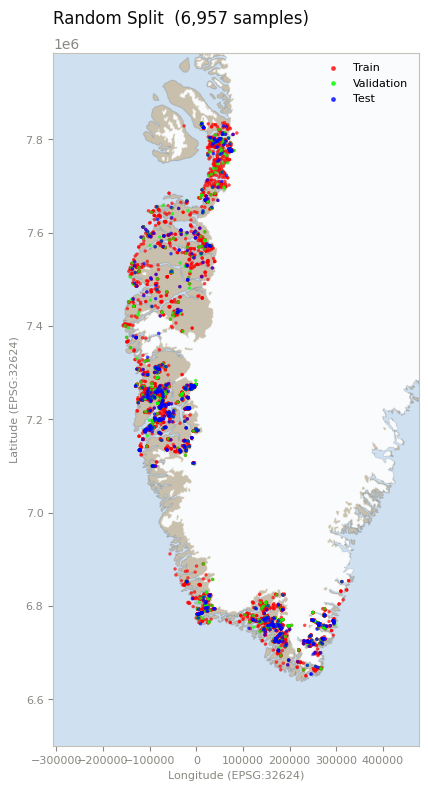

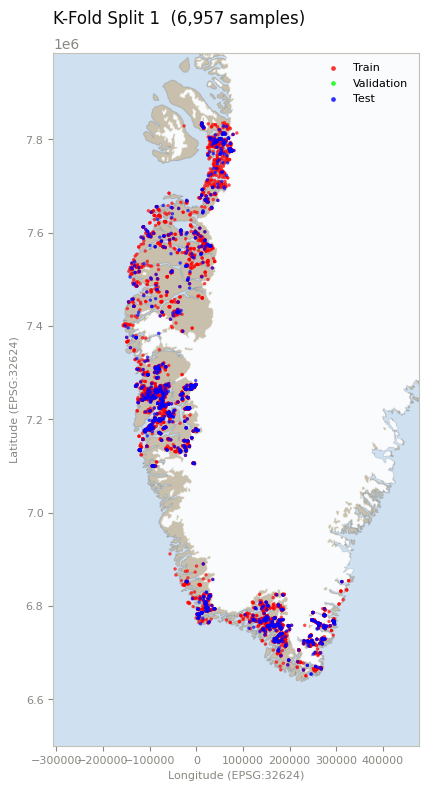

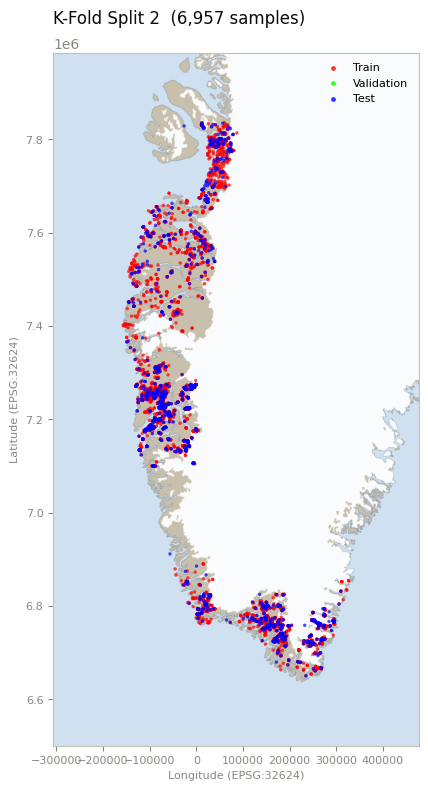

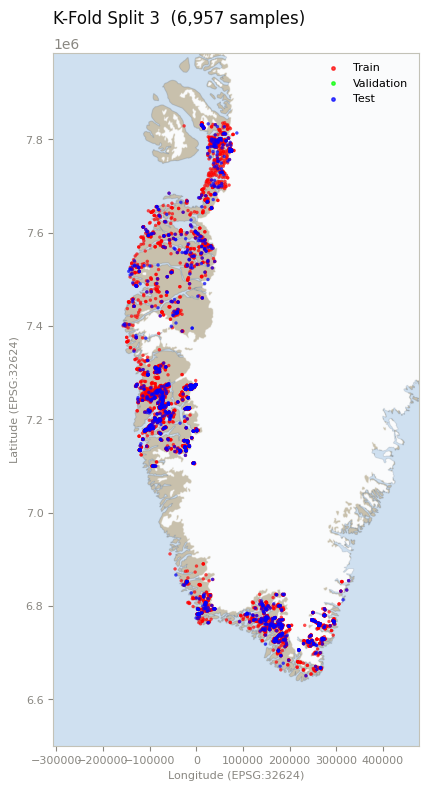

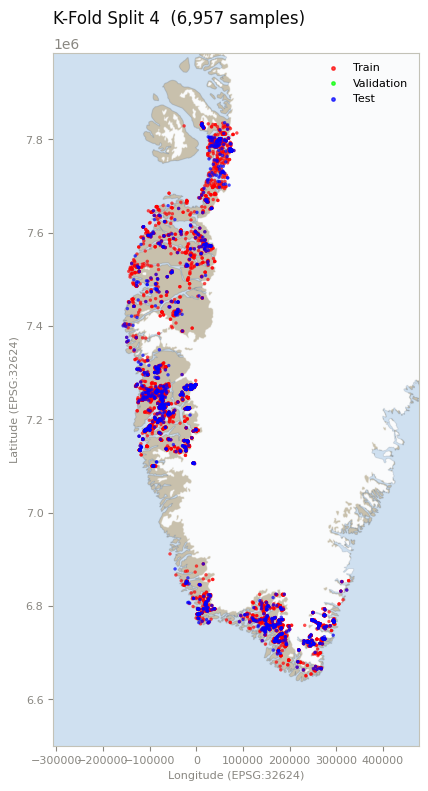

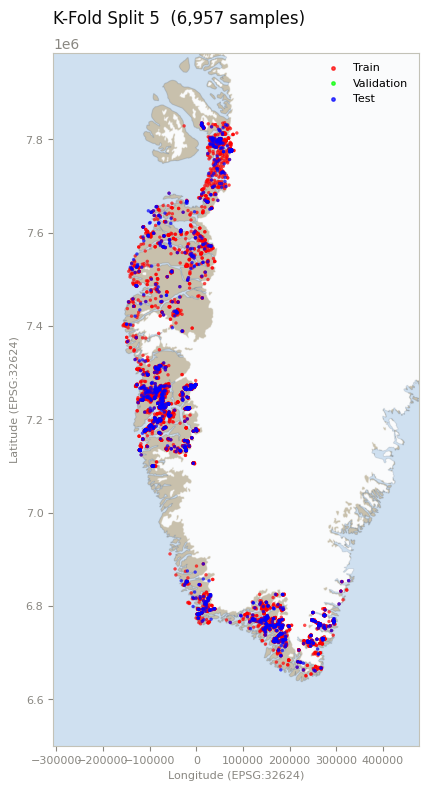

In [8]:
displaySplit(split.data, title="Random Split")

for i, kfold_split in enumerate(kfold_splits):
    displaySplit(kfold_split.data, title=f"K-Fold Split {i+1}")

### Nearest Neighbours

In [8]:
dfKNN = pd.read_csv(f"Data/{DATA_TYPE}/{MERGE_TYPE}/Data_KNN.csv", sep=";")

##### Building Neighbour Mapping

Takes a dataframe with location coordinates and a split and creates the NN mapping (only with train context)

In [12]:
from GreenlandUtils import lonlatToUTM24N

def ProjectedCoords(df: pd.DataFrame, lonCol: str = "Longitude", latCol: str = "Latitude") -> np.ndarray:
    x, y = lonlatToUTM24N(df[lonCol].to_numpy(dtype=float), df[latCol].to_numpy(dtype=float))
    return np.column_stack([x, y])


def NearestNeighbours(context: pd.DataFrame, entry: pd.Series, n: int):
    
    #Get projected coords version
    contextCoords = ProjectedCoords(context, lonCol="Longitude", latCol="Latitude")
    entryCoords = ProjectedCoords(entry.to_frame().T, lonCol="Longitude", latCol="Latitude")[0]

    #Calculate distances
    distances = np.linalg.norm(contextCoords - entryCoords, axis=1)

    #Exclude self
    distances[context.index == entry.name] = np.inf

    #Get nearest neighbours
    nearest_indices = np.argsort(distances)[:n]
    return context.iloc[nearest_indices]        
        
def BuildNearestNeighboursData(df: pd.DataFrame, split : Split, n:int=20, path:str="Data/{DATA_TYPE}/{MERGE_TYPE}/", baseName:str="NearestNeighbours"):
    idx = []
    
    for i, row in tqdm(df.iterrows(), total=df.shape[0], desc="Building Nearest Neighbours Data"):
        nn = NearestNeighbours(split.data["train"], row, n)
        idx.append((i, nn.index.tolist()))
        
    with open(f"{path}{baseName}.json", "w") as f:
        json.dump(dict(idx), f, indent=4)
        

DATA_TYPE = "Whole Rock"
MERGE_TYPE = "Mean Merge"
BuildNearestNeighboursData(mergedDF, split, n=20, path=f"Data/{DATA_TYPE}/{MERGE_TYPE}/")

Building Nearest Neighbours Data: 100%|██████████| 6957/6957 [00:26<00:00, 261.99it/s]


In [13]:
#K-Fold Nearest Neighbours
for i, kfold_split in enumerate(kfold_splits):
    BuildNearestNeighboursData(dfKNN, kfold_split, n=20, path=f"Data/{DATA_TYPE}/{MERGE_TYPE}/Folds/", baseName=f"NearestNeighbours-Fold-{i+1}")

Building Nearest Neighbours Data: 100%|██████████| 6957/6957 [00:44<00:00, 158.11it/s]


##### Create Nearest Neighbour Data

Takes a Dataframe, a split and a NN map and creates a new Dataframe with the information of the elements of the neighbours

In [17]:
from tqdm.auto import tqdm


def NearestNeighboursEntries(df: pd.DataFrame, entry: pd.Series, n: int, nns: dict[int, list[int]]) -> pd.DataFrame:
    if entry.name not in nns:
        return
    
    nearest_idx = nns[entry.name][:n]
    nearest_entries = df.loc[nearest_idx]
    return nearest_entries

def ReadNearestNeighbours(path: str, baseName: str) -> dict[int, list[int]]:
    with open(f"{path}{baseName}.json", "r") as f:
        json_result = json.load(f)
    return {int(k): v for k, v in json_result.items()}

tqdm.pandas(desc="Processing Rows")

#Entry Builder
def BuildKNNFullEntry(entry: pd.Series, df: pd.DataFrame, n:int, elementCols: list[str], local_nns: dict[int, list[int]], verbose: bool = False) -> pd.Series:
    #df is the context only
    nearestNeighbours = NearestNeighboursEntries(df, entry, n, local_nns)
    
    entry_copy = entry.copy()
    
    total = len(elementCols) * len(nearestNeighbours)
    pbar = tqdm(total=total, desc="Processing KNN", disable=not verbose)

    for element in elementCols:
        mean_value = nearestNeighbours[element].mean()
        entry_copy[f"{n}-KNN_{element}_mean"] = mean_value

        for i in range(len(nearestNeighbours)):
            entry_copy[f"{i+1}of{n}-KNN_{element}"] = nearestNeighbours.iloc[i][element]
            pbar.update(1)

    pbar.close()
    return entry_copy


In [18]:
# dfKNN = df.progress_apply(lambda entry: BuildKNNFullEntry(entry, df, n=5, elementCols=elementCols, verbose=False), axis=1)
# dfKNN.to_csv(f"Data/{DATA_TYPE}/{MERGE_TYPE}/Data_KNN.csv", sep=";", index=False)

elementCols = [col for col in mergedDF.columns if col not in metaCols]

for i, kfold_split in enumerate(kfold_splits):
    kfold_nns = ReadNearestNeighbours(f"Data/{DATA_TYPE}/{MERGE_TYPE}/Folds/", f"NearestNeighbours-Fold-{i+1}")
    dfKNN_fold = mergedDF.progress_apply(lambda entry: BuildKNNFullEntry(entry, kfold_split.data["train"], n=5, elementCols=elementCols, verbose=False, local_nns=kfold_nns), axis=1)
    dfKNN_fold.to_csv(f"Data/{DATA_TYPE}/{MERGE_TYPE}/Folds/Data_KNN_Fold_{i+1}.csv", sep=";", index=False)

Processing Rows:   0%|          | 0/6957 [00:00<?, ?it/s]

Processing Rows:   0%|          | 0/6957 [00:00<?, ?it/s]

Processing Rows:   0%|          | 0/6957 [00:00<?, ?it/s]

Processing Rows:   0%|          | 0/6957 [00:00<?, ?it/s]

Processing Rows:   0%|          | 0/6957 [00:00<?, ?it/s]